## Decision Tree Model for Titanic Survival Prediction

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [2]:
df = pd.read_csv('/content/titanic.csv')
print("Titanic dataset loaded successfully.")

print("\nFirst 5 rows of the dataset:")
display(df.head())
print("\nDataset Information:")
display(df.info())

Titanic dataset loaded successfully.

First 5 rows of the dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

In [3]:
features = ['Pclass', 'Sex', 'Age', 'Fare']
target = 'Survived'
data = df[features + [target]].copy()

data['Age'].fillna(data['Age'].median(), inplace=True)

data['Fare'].fillna(data['Fare'].median(), inplace=True)

data = pd.get_dummies(data, columns=['Sex'], drop_first=True)

data['Pclass'] = data['Pclass'].astype('category')
data = pd.get_dummies(data, columns=['Pclass'], prefix='Pclass', drop_first=True)

print("\nPreprocessed Data Information:")
display(data.info())
print("\nFirst 5 rows of preprocessed data:")
display(data.head())

X = data.drop(target, axis=1)
y = data[target]


Preprocessed Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       891 non-null    float64
 1   Fare      891 non-null    float64
 2   Survived  891 non-null    int64  
 3   Sex_male  891 non-null    bool   
 4   Pclass_2  891 non-null    bool   
 5   Pclass_3  891 non-null    bool   
dtypes: bool(3), float64(2), int64(1)
memory usage: 23.6 KB


/tmp/ipykernel_3503/668888135.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
/tmp/ipykernel_3503/668888135.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

None


First 5 rows of preprocessed data:


,Age,Fare,Survived,Sex_male,Pclass_2,Pclass_3
0,22.0,7.2500,0,True,False,True
1,38.0,71.2833,1,False,False,False
2,26.0,7.9250,1,False,False,True
3,35.0,53.1000,1,False,False,False
4,35.0,8.0500,0,True,False,True


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")


Training set size: 712 samples
Testing set size: 179 samples


In [5]:
dtree = DecisionTreeClassifier(random_state=42)

dtree.fit(X_train, y_train)
print("Decision Tree Model trained successfully.")

Decision Tree Model trained successfully.



Model Accuracy Score: 0.7542


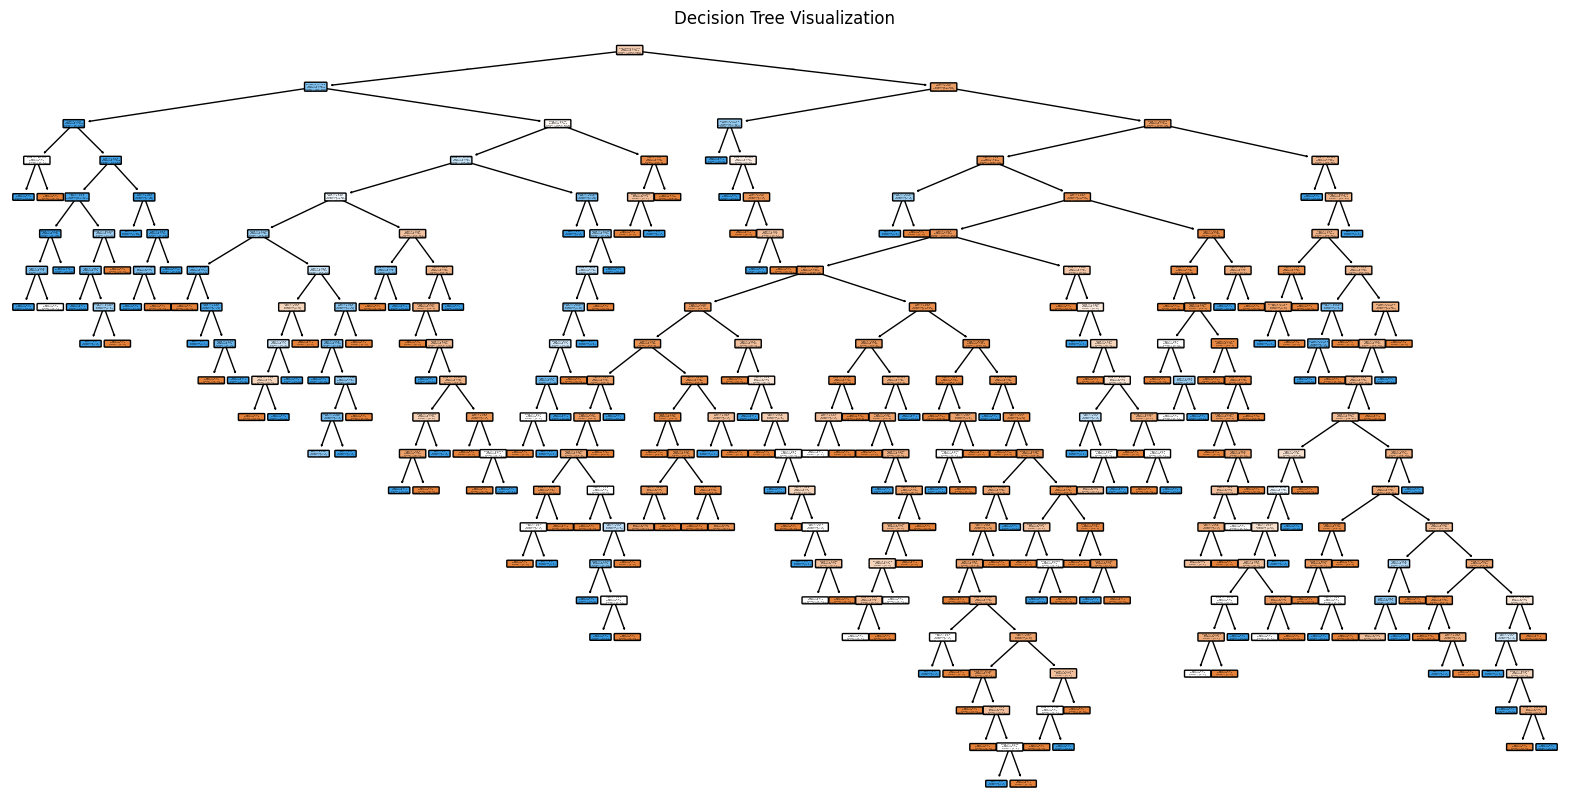

In [6]:
y_pred = dtree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy Score: {accuracy:.4f}")

plt.figure(figsize=(20,10))
plot_tree(dtree, filled=True, feature_names=X.columns.tolist(), class_names=['Not Survived', 'Survived'], rounded=True)
plt.title("Decision Tree Visualization")
plt.show()